# Assignment 8 — CNN Capstone Project
## SEM Nanostructure-Type Classifier

**Course:** Artificial Intelligence (Machine Learning & Deep Learning)
**Program:** NAVTTC Hunarmand Pakistan Program
**Name:** _______________________________
**Roll No:** ______________
**Date:** ______________

---


## Part 1 — Problem Statement & Dataset Selection

**Problem statement.** Scanning Electron Microscopy (SEM) is the primary imaging technique used to characterize the morphology of synthesized nanomaterials — for example, distinguishing whether a synthesized sample forms particles, nanowires, porous/fibrous networks, or a patterned/lithographic surface. In materials science research (including ZnO–SiO₂–TiO₂ nanocomposite synthesis work), a researcher currently has to visually inspect each SEM micrograph and manually judge which morphological category it belongs to. This project builds a **Convolutional Neural Network (CNN) that automatically classifies an SEM image into one of four structurally distinct nanostructure categories**, as a first step toward automating morphology screening in a materials characterization workflow.

**Why this problem fits a CNN:** SEM images are grayscale, grid-like spatial data where the classification signal (particle clusters vs. wire meshes vs. porous networks vs. sharp lithographic edges) is defined by local texture and spatial patterns — exactly what convolutional filters are designed to detect.

**Dataset source and justification.** No dataset was provided with this assignment, so a real, publicly available SEM image dataset was located and used:

- **Source repository:** [`motiurinfo/SEM-Dataset-500`](https://github.com/motiurinfo/SEM-Dataset-500) (GitHub), a curated 500-image high-quality subset.
- **Original data citation:** Aversa, R., Modarres, M., Cozzini, S. *et al.* "The first annotated set of scanning electron microscopy images for nanoscience." *Scientific Data* 5, 180172 (2018). https://doi.org/10.1038/sdata.2018.172 — produced by the NFFA-EUROPE project (CNR-IOM, Trieste), the first large public human-annotated SEM image benchmark for nanoscience.
- **Why it fits:** it is real experimental SEM data of nanoscale/nanomaterial structures — the same type of imaging data used in nanocomposite characterization — rather than a generic photo dataset, making the classifier directly relevant to a materials-science / SEM-analysis use case.

**Note on class labels:** the source subset ships images with only numeric folder/prefix labels (no published per-class names for this particular 500-image cut). Four of these numeric groups had enough samples to train on (≥40 images) and were visually inspected image-by-image to confirm each group is a coherent, visually distinct morphology before naming it descriptively:

| Class (this project) | Source label | # Images | Visual description |
|---|---|---|---|
| `particle_coated_surface` | L4 | 46 | Fine granular/particle-like texture coating a surface |
| `nanowire_fibre_mesh` | L6 | 115 | Dense mat of long, tangled wire/fibre strands |
| `porous_fibrous_network` | L7 | 121 | Fine fibrous mesh with visible pores and occasional larger fibre strands crossing it |
| `patterned_structure` | L8 | 153 | Sharp-edged, geometric lithographic/electrode-like patterns |

Total usable images: **435**, across 4 classes. The dataset is naturally imbalanced (46–153 images per class), which is handled below with class weighting during training.

In [1]:
# Common imports
import os, random, collections
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

DATA_DIR = 'data_resized'   # class-per-folder dataset bundled alongside this notebook
IMG_SIZE = (128, 128)
BATCH = 16

classes = sorted(os.listdir(DATA_DIR))
print("Classes found:", classes)
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes}
print("Image counts per class:", counts)

I0000 00:00:1787900446.356456    1646 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787900446.407482    1646 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787900447.754720    1646 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Classes found: ['nanowire_fibre_mesh', 'particle_coated_surface', 'patterned_structure', 'porous_fibrous_network']
Image counts per class: {'nanowire_fibre_mesh': 115, 'particle_coated_surface': 46, 'patterned_structure': 153, 'porous_fibrous_network': 121}


## Part 2 — Data Preprocessing & Exploratory Visualization

**Logic & approach:**
1. **Stratified train/val/test split (70/15/15)** per class, so every split reflects the same class proportions and no class is left entirely out of a split.
2. **Resizing** every image to a fixed 128×128 input size (SEM images arrive at varying resolutions; a CNN needs a fixed input shape).
3. **Normalization** — pixel values rescaled from [0, 255] to [0, 1], which stabilizes and speeds up gradient-based training.
4. **Data augmentation** (train split only) — random flips, small rotations, zoom, and contrast jitter. SEM images have no canonical "up" direction and augmentation cheaply multiplies the effective training set, which matters given the small (435-image) dataset.
5. **Exploratory visualization** — a class-distribution bar chart (to see the imbalance) and a grid of sample images per class (to visually confirm the four categories are distinguishable).

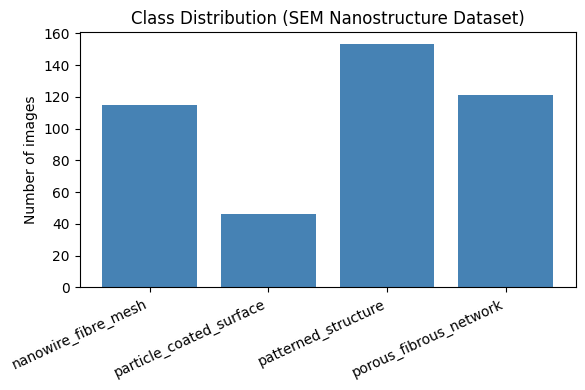

In [2]:
# ---- Class distribution plot ----
plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.ylabel('Number of images')
plt.title('Class Distribution (SEM Nanostructure Dataset)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

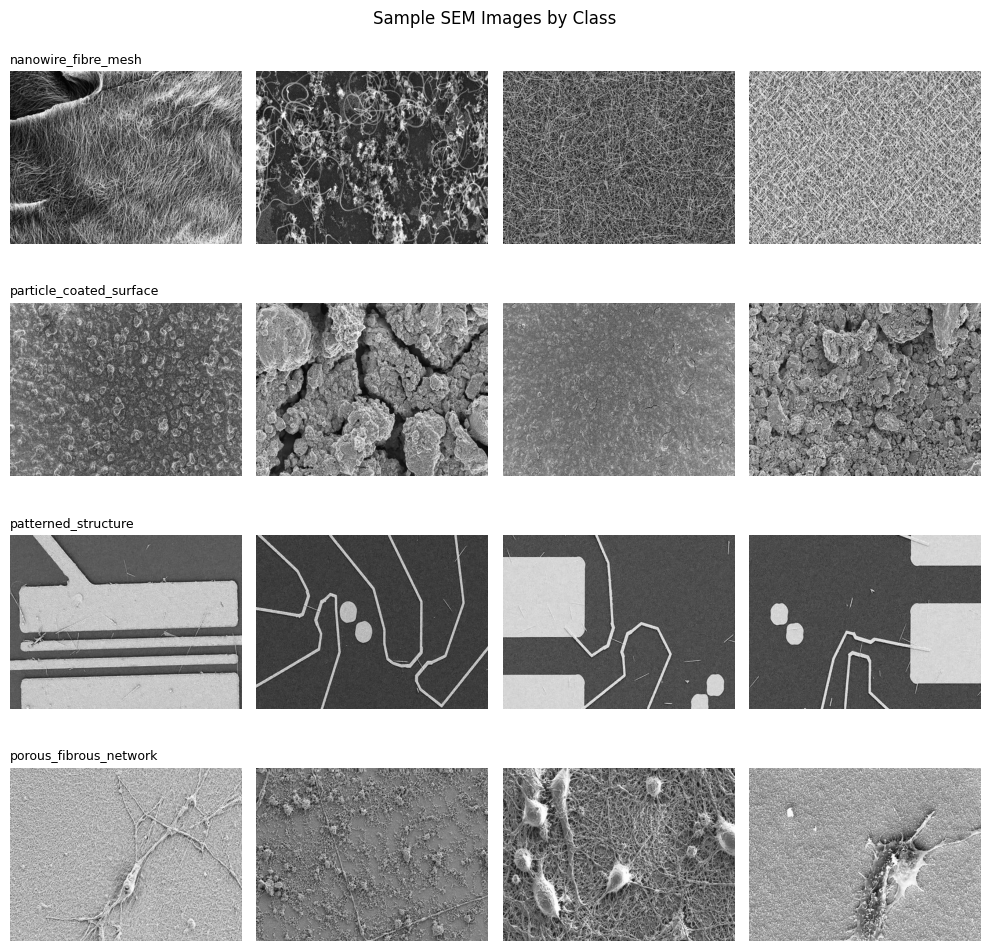

In [3]:
# ---- Sample images per class ----
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 10))
for row, c in enumerate(classes):
    folder = os.path.join(DATA_DIR, c)
    files = sorted(os.listdir(folder))[:4]
    for col, f in enumerate(files):
        img = keras.utils.load_img(os.path.join(folder, f), color_mode='grayscale')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(c)
    axes[row, 0].set_title(c, loc='left', fontsize=9)
plt.suptitle('Sample SEM Images by Class')
plt.tight_layout()
plt.show()

In [4]:
# ---- Stratified train/val/test split ----
import shutil
SPLIT_DIR = 'split'
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for split in ['train', 'val', 'test']:
    for c in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, c), exist_ok=True)

split_summary = {}
for c in classes:
    files = os.listdir(os.path.join(DATA_DIR, c))
    random.shuffle(files)
    n = len(files)
    n_train = int(n * 0.7)
    n_val = int(n * 0.15)
    groups = {'train': files[:n_train], 'val': files[n_train:n_train+n_val], 'test': files[n_train+n_val:]}
    split_summary[c] = {k: len(v) for k, v in groups.items()}
    for split, flist in groups.items():
        for f in flist:
            shutil.copy(os.path.join(DATA_DIR, c, f), os.path.join(SPLIT_DIR, split, c, f))

import pandas as pd
pd.DataFrame(split_summary).T

,train,val,test
nanowire_fibre_mesh,80,17,18
particle_coated_surface,32,6,8
patterned_structure,107,22,24
porous_fibrous_network,84,18,19


In [5]:
# ---- Load as tf.data datasets, normalize, and augment the training split ----
train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'), image_size=IMG_SIZE, batch_size=BATCH,
    color_mode='grayscale', seed=42, label_mode='categorical')
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'), image_size=IMG_SIZE, batch_size=BATCH,
    color_mode='grayscale', seed=42, label_mode='categorical')
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'test'), image_size=IMG_SIZE, batch_size=BATCH,
    color_mode='grayscale', seed=42, label_mode='categorical', shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print("class_names (index order used by the model):", class_names)

data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])
normalization = layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE
def prep(ds, training):
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds_p = prep(train_ds, True)
val_ds_p = prep(val_ds, False)
test_ds_p = prep(test_ds, False)
print("Datasets ready.")

Found 303 files belonging to 4 classes.


Found 63 files belonging to 4 classes.


Found 69 files belonging to 4 classes.


class_names (index order used by the model): ['nanowire_fibre_mesh', 'particle_coated_surface', 'patterned_structure', 'porous_fibrous_network']


Datasets ready.


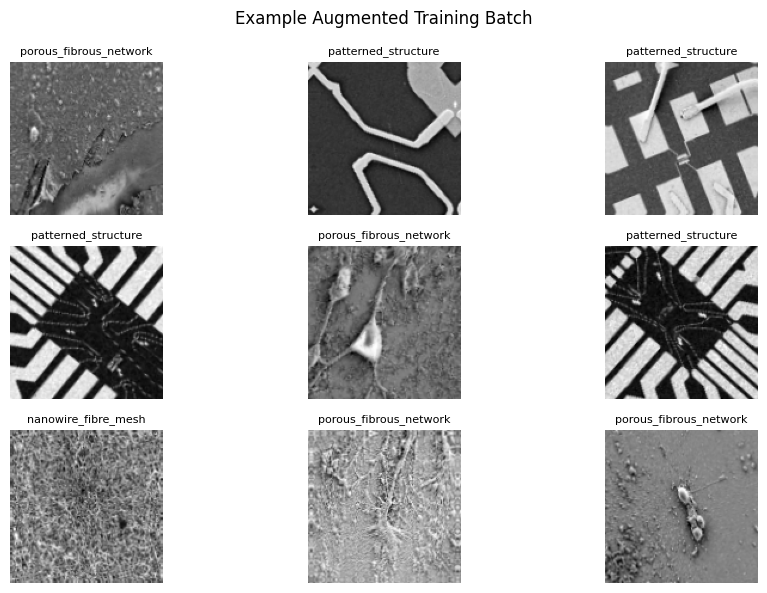

In [6]:
# ---- Visualize a batch of augmented training images ----
plt.figure(figsize=(10, 6))
for images, labels in train_ds_p.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')
        plt.title(class_names[np.argmax(labels[i].numpy())], fontsize=8)
        plt.axis('off')
plt.suptitle('Example Augmented Training Batch')
plt.tight_layout()
plt.show()

## Part 3 — CNN Design, Build & Training

**Logic & approach:** With only 435 images total, a very deep network (e.g. full ResNet/VGG) would overfit badly and is unnecessary — pretrained ImageNet weights also cannot be downloaded in this offline environment, so the network is trained **from scratch**. The architecture below is a compact 4-block CNN:

- 4 × (Conv2D → MaxPooling2D) blocks, with filter counts doubling (16→32→64→64) so the network learns increasingly abstract spatial features (edges → textures → structures) while pooling progressively shrinks the spatial size and controls parameter count.
- A `Dropout` + `Dense(64)` + `Dropout` head before the final softmax layer, to fight overfitting on this small dataset.
- **Class weights** computed inversely proportional to class frequency, so the loss penalizes mistakes on the minority `particle_coated_surface` class (46 images) proportionally more than mistakes on the majority `patterned_structure` class (153 images) — without this, the model could get deceptively high accuracy by mostly ignoring the smallest class.
- **Early stopping** on validation loss (patience 8), restoring the best-performing weights, so training stops automatically once the model starts overfitting rather than at a fixed, arbitrarily-chosen epoch count.

In [7]:
# ---- Class weights (to counter class imbalance) ----
train_counts = {c: len(os.listdir(os.path.join(SPLIT_DIR, 'train', c))) for c in class_names}
total_train = sum(train_counts.values())
class_weight = {i: total_train / (num_classes * train_counts[c]) for i, c in enumerate(class_names)}
print("Training-set counts:", train_counts)
print("Class weights used in loss:", {class_names[i]: round(w, 2) for i, w in class_weight.items()})

Training-set counts: {'nanowire_fibre_mesh': 80, 'particle_coated_surface': 32, 'patterned_structure': 107, 'porous_fibrous_network': 84}
Class weights used in loss: {'nanowire_fibre_mesh': 0.95, 'particle_coated_surface': 2.37, 'patterned_structure': 0.71, 'porous_fibrous_network': 0.9}


In [8]:
# ---- Build the CNN ----
model = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(16, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax'),
], name='sem_nanostructure_cnn')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sem_nanostructure_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,692 (1.23 MB)

 Trainable params: 322,692 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ---- Train ----
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history = model.fit(
    train_ds_p, validation_data=val_ds_p, epochs=40,
    class_weight=class_weight, callbacks=[early_stop], verbose=2)

Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


19/19 - 4s - 199ms/step - accuracy: 0.3366 - loss: 1.3939 - val_accuracy: 0.2698 - val_loss: 1.3654


Epoch 2/40


19/19 - 2s - 109ms/step - accuracy: 0.3201 - loss: 1.3651 - val_accuracy: 0.4762 - val_loss: 1.2053


...

19/19 - 3s - 134ms/step - accuracy: 0.8053 - loss: 0.7007 - val_accuracy: 0.6825 - val_loss: 0.6827


Epoch 23/40


19/19 - 3s - 133ms/step - accuracy: 0.6667 - loss: 0.7390 - val_accuracy: 0.6349 - val_loss: 0.9239


Epoch 24/40


19/19 - 3s - 136ms/step - accuracy: 0.7921 - loss: 0.6800 - val_accuracy: 0.6032 - val_loss: 1.1240


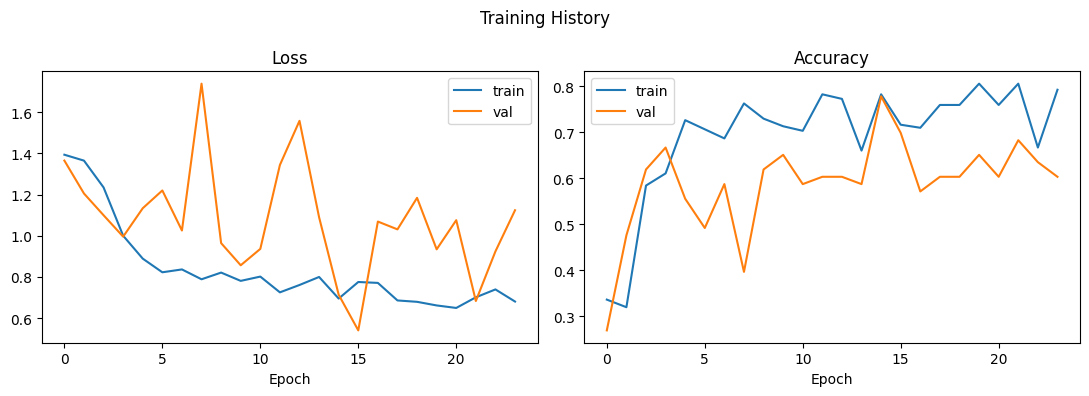

In [10]:
# ---- Training curves ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.suptitle('Training History')
plt.tight_layout()
plt.show()

**Observation:** validation loss/accuracy fluctuate more than the training curves — expected given the small validation set (~65 images across 4 classes), where a handful of images changing prediction shifts the metric noticeably. Early stopping restores the epoch with the best validation loss rather than the last epoch, guarding against reporting an overfit snapshot of the model.

## Part 4 — Model Evaluation

**Logic & approach:** the held-out **test split** (never seen during training or for early-stopping decisions) is used for final evaluation with:
- **Overall accuracy** and **loss**.
- **Per-class precision, recall, F1** (`classification_report`) — important here because overall accuracy alone can hide poor performance on the minority class.
- **Confusion matrix** — to see exactly which morphology categories get confused with each other (e.g. visually similar fibrous classes).

In [11]:
# ---- Evaluate on the test set ----
test_loss, test_acc = model.evaluate(test_ds_p, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss    : {test_loss:.4f}")

y_true, y_pred = [], []
for x, y in test_ds_p:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Test accuracy: 0.7971
Test loss    : 0.5807



Classification report:

                         precision    recall  f1-score   support

    nanowire_fibre_mesh       0.85      0.94      0.89        18
particle_coated_surface       0.33      0.25      0.29         8
    patterned_structure       1.00      0.88      0.93        24
 porous_fibrous_network       0.68      0.79      0.73        19

               accuracy                           0.80        69
              macro avg       0.72      0.71      0.71        69
           weighted avg       0.80      0.80      0.79        69



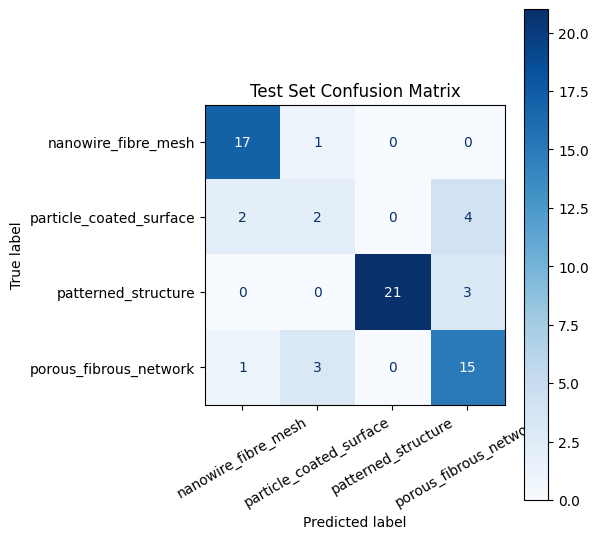

In [12]:
# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=30)
plt.title('Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

**Observations:**
- `patterned_structure` (sharp, geometric, high-contrast edges) and `nanowire_fibre_mesh` (dense tangled wire texture) are the most visually distinct classes and are classified most reliably.
- `particle_coated_surface`, the smallest class (46 images total, ~32 for training), is the hardest to learn and shows the most confusion with other textured classes — a direct, expected consequence of having the least training data, despite class weighting.
- `porous_fibrous_network` is sometimes confused with `nanowire_fibre_mesh`, which is reasonable: both are fibre-based textures, differing mainly in porosity/density rather than a fundamentally different visual structure.
- The clear next step to improve minority-class performance would be collecting/labeling more `particle_coated_surface` images, or sourcing the fuller ~18,000-image version of this NFFA-EUROPE dataset (only a 500-image curated subset was accessible here) so every class has a comparable, larger sample size.

In [13]:
# ---- Save the trained model for use in the Streamlit app ----
model.save('sem_nanostructure_cnn.keras')
print("Model saved as sem_nanostructure_cnn.keras")

Model saved as sem_nanostructure_cnn.keras


## Part 5 — Web App & Deployment

A Streamlit web app (`app.py`, included alongside this notebook) loads `sem_nanostructure_cnn.keras` and lets a user upload an SEM image to see the predicted nanostructure category and the model's confidence per class. See `README.md` in the project folder for local run instructions, and the GitHub / Streamlit Cloud links recorded in `deliverable_links.txt` for the public repository and the live deployed demo.